# **Optimización de Rutas mediante ACO (Ant Colony Optimization) — Acelerado por GPU**
**Por:** Guillermo Andres De Mendoza Corrales

---
## Descripción
Implementación del algoritmo ACO (Colonia de Hormigas) sobre una matriz 2D con obstáculos,
acelerado con GPU mediante **Numba CUDA** (T4 en Google Colab).
La visualización se realiza con **Matplotlib** adaptado al entorno Colab.

> **Nota sobre visualización:** el enunciado sugiere `tkinter` para la animación en tiempo real.
> En Google Colab, `tkinter` no tiene acceso a pantalla (entorno headless), por lo que se utiliza
> `matplotlib.animation` con renderizado HTML5, que es el equivalente funcional en este entorno.

### Mejoras implementadas
| Área | Mejora |
|------|--------|
| GPU | Kernel `kernel_deposito` paraleliza el depósito de feromonas en GPU |
| GPU | Kernel `kernel_probabilidades` calcula pesos τ^α·η^β en paralelo por hormiga |
| Algoritmo | Backtracking: hormiga retrocede al último punto con vecinos disponibles |
| Algoritmo | `max_pasos` adaptativo basado en la distancia Manhattan origen-destino |
| Algoritmo | Fix precisión flotante en ruleta estocástica |
| Visualización | Hormigas activas mostradas como puntos en la animación |
| Visualización | Gradiente de color feromonas con colormap `inferno` |
| Visualización | Barra de progreso de iteración en el panel de info |

### Estructura del notebook
| Paso | Descripción |
|------|-------------|
| 1 | Importaciones y configuración CUDA |
| 2 | Parámetros del algoritmo ACO |
| 3 | Generación aleatoria del entorno |
| 4 | Kernels GPU (heurística, evaporación, depósito, probabilidades) |
| 5 | Lógica ACO con backtracking |
| 6 | Ciclo principal |
| 7 | Curva de convergencia |
| 8 | Animación mejorada |
| 9 | Resultado final |

## **Paso 1 — Importaciones y configuración CUDA**

In [1]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from IPython.display import HTML, display
import random
import math
import time

# ── Numba CUDA ────────────────────────────────────────────────────────────────
from numba import cuda, config
from numba import float32, int32

# Habilita el enlazador JIT de CUDA requerido en versiones recientes de Numba
config.CUDA_ENABLE_PYNVJITLINK = 1

# ── Verificación de GPU ───────────────────────────────────────────────────────
gpu = cuda.get_current_device()
mem_free, mem_total = cuda.current_context().get_memory_info()
mem_total_gb = mem_total / (1024 ** 3)
print(f"GPU detectada : {gpu.name}")
print(f"Compute Cap.  : {gpu.compute_capability}")
print(f"Memoria total : {mem_total_gb:.2f} GB — listo para ejecutar kernels CUDA")

GPU detectada : Tesla T4
Compute Cap.  : ComputeCapability(major=7, minor=5)
Memoria total : 14.56 GB — listo para ejecutar kernels CUDA


## **Paso 2 — Parámetros del algoritmo ACO**
Todos los valores se generan aleatoriamente dentro de rangos razonables.
Los parámetros adicionales `α`, `β` y `Q` no están en el enunciado original
pero son componentes estándar de ACO requeridos para la fórmula de selección probabilística.

In [2]:
# ── Semilla aleatoria ─────────────────────────────────────────────────────────
SEED = random.randint(0, 9999)
random.seed(SEED)
np.random.seed(SEED)

# ── Dimensiones del mapa ──────────────────────────────────────────────────────
COLS = random.randint(15, 25)          # X: cantidad de columnas
ROWS = random.randint(15, 25)          # Y: cantidad de filas

# ── Parámetros ACO ────────────────────────────────────────────────────────────
N_ANTS       = random.randint(20, 60)               # N: cantidad de hormigas
M_ITER       = random.randint(80, 150)              # M: cantidad de iteraciones
ALPHA        = round(random.uniform(0.5, 2.0), 2)  # α: importancia de feromonas
BETA         = round(random.uniform(1.0, 4.0), 2)  # β: importancia de heurística
RHO          = round(random.uniform(0.1, 0.4), 2)  # ρ: tasa de evaporación
TAU_INIT     = round(random.uniform(0.5, 1.5), 2)  # τ₀: feromonas iniciales
Q            = round(random.uniform(50.0, 200.0), 1) # Q: constante de depósito
OBSTACLE_PCT = round(random.uniform(0.15, 0.28), 2) # % de obstáculos en el mapa
TAU_MIN      = 1e-4   # τ_min: piso mínimo de feromonas (evita extinción)

# ── Resumen de configuración ──────────────────────────────────────────────────
print("="*55)
print("       PARÁMETROS DEL EXPERIMENTO ACO")
print("="*55)
print(f"  Semilla aleatoria (SEED)  : {SEED}")
print(f"  Dimensiones del mapa      : {COLS} cols x {ROWS} filas")
print(f"  N — Hormigas              : {N_ANTS}")
print(f"  M — Iteraciones           : {M_ITER}")
print(f"  α — Peso feromonas        : {ALPHA}")
print(f"  β — Peso heurística       : {BETA}")
print(f"  ρ — Tasa evaporación      : {RHO}")
print(f"  τ₀ — Feromonas iniciales  : {TAU_INIT}")
print(f"  τ_min — Piso feromonas    : {TAU_MIN}")
print(f"  Q  — Constante depósito   : {Q}")
print(f"  % Obstáculos              : {int(OBSTACLE_PCT*100)}%")
print("="*55)

       PARÁMETROS DEL EXPERIMENTO ACO
  Semilla aleatoria (SEED)  : 5957
  Dimensiones del mapa      : 17 cols x 22 filas
  N — Hormigas              : 59
  M — Iteraciones           : 84
  α — Peso feromonas        : 1.76
  β — Peso heurística       : 2.42
  ρ — Tasa evaporación      : 0.32
  τ₀ — Feromonas iniciales  : 1.18
  τ_min — Piso feromonas    : 0.0001
  Q  — Constante depósito   : 76.6
  % Obstáculos              : 21%


## **Paso 3 — Generación aleatoria del entorno**
Se construyen dos matrices:
- `grid`: mapa del entorno (`0`=libre, `1`=obstáculo, `2`=origen, `3`=destino)
- `pheromone`: matriz de feromonas inicializada en `τ₀` para celdas libres

Mapa generado  : 22 filas x 17 cols
Origen         : fila 7, col 15
Destino        : fila 0,  col 0
Distancia Manhattan origen-destino: 22 pasos
Obstáculos     : 78 celdas
Celdas libres  : 296 celdas


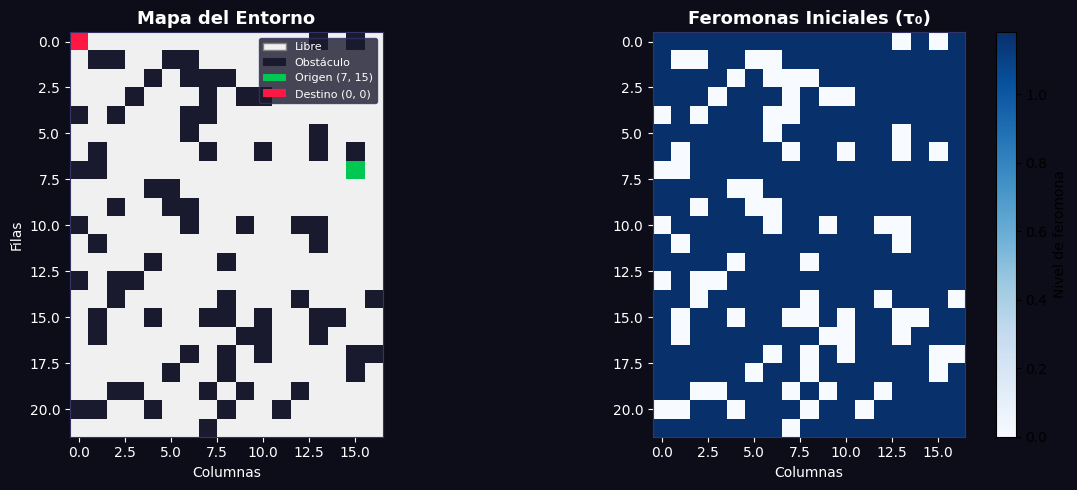

In [3]:
# ── Constantes de tipo de celda ───────────────────────────────────────────────
FREE     = 0
OBSTACLE = 1
ORIGIN   = 2
FOOD     = 3

def generate_map(rows, cols, obstacle_pct, seed):
    """
    Genera un mapa aleatorio con obstáculos, origen y destino.
    Garantiza que origen y destino sean siempre accesibles.

    Parámetros
    ----------
    rows, cols    : dimensiones de la matriz
    obstacle_pct  : fracción de celdas que serán obstáculos
    seed          : semilla para reproducibilidad

    Retorna
    -------
    grid   : np.ndarray (rows, cols) int32
    origin : tupla (row, col)
    food   : tupla (row, col)
    """
    rng  = np.random.default_rng(seed)
    grid = np.zeros((rows, cols), dtype=np.int32)

    n_obstacles  = int(rows * cols * obstacle_pct)
    flat_indices = rng.choice(rows * cols, size=n_obstacles, replace=False)
    for idx in flat_indices:
        r, c = divmod(idx, cols)
        grid[r, c] = OBSTACLE

    free_cells = [(r, c) for r in range(rows) for c in range(cols) if grid[r, c] == FREE]
    min_dist   = max(rows, cols) // 2

    for _ in range(5000):
        o = free_cells[rng.integers(0, len(free_cells))]
        f = free_cells[rng.integers(0, len(free_cells))]
        if abs(o[0]-f[0]) + abs(o[1]-f[1]) >= min_dist:
            break

    grid[o[0], o[1]] = ORIGIN
    grid[f[0], f[1]] = FOOD
    return grid, o, f


grid, ORIGIN_POS, FOOD_POS = generate_map(ROWS, COLS, OBSTACLE_PCT, SEED)
pheromone = np.where(grid != OBSTACLE, TAU_INIT, 0.0).astype(np.float32)

print(f"Mapa generado  : {ROWS} filas x {COLS} cols")
print(f"Origen         : fila {ORIGIN_POS[0]}, col {ORIGIN_POS[1]}")
print(f"Destino        : fila {FOOD_POS[0]},  col {FOOD_POS[1]}")
print(f"Distancia Manhattan origen-destino: {abs(ORIGIN_POS[0]-FOOD_POS[0])+abs(ORIGIN_POS[1]-FOOD_POS[1])} pasos")
print(f"Obstáculos     : {np.sum(grid == OBSTACLE)} celdas")
print(f"Celdas libres  : {np.sum(grid != OBSTACLE)} celdas")

# ── Visualización del mapa inicial ───────────────────────────────────────────
import matplotlib.colors as mcolors
cmap_grid = mcolors.ListedColormap(['#f0f0f0', '#1a1a2e', '#00c853', '#ff1744'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0d0d1a')
for ax in axes:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333366')

axes[0].imshow(grid, cmap=cmap_grid, vmin=0, vmax=3, interpolation='nearest')
axes[0].set_title('Mapa del Entorno', fontsize=13, fontweight='bold', color='white')
axes[0].set_xlabel('Columnas', color='white')
axes[0].set_ylabel('Filas', color='white')
legend_elements = [
    mpatches.Patch(facecolor='#f0f0f0', edgecolor='gray', label='Libre'),
    mpatches.Patch(facecolor='#1a1a2e', label='Obstáculo'),
    mpatches.Patch(facecolor='#00c853', label=f'Origen {ORIGIN_POS}'),
    mpatches.Patch(facecolor='#ff1744', label=f'Destino {FOOD_POS}'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8,
               facecolor='#1a1a2e', labelcolor='white', edgecolor='#333366')

im_pher = axes[1].imshow(pheromone, cmap='Blues', interpolation='nearest')
axes[1].set_title('Feromonas Iniciales (τ₀)', fontsize=13, fontweight='bold', color='white')
axes[1].set_xlabel('Columnas', color='white')
plt.colorbar(im_pher, ax=axes[1], label='Nivel de feromona')

plt.tight_layout()
plt.show()

## **Paso 4 — Kernels CUDA (GPU)**
Se definen **4 kernels** que corren en paralelo sobre la GPU:
1. `kernel_heuristica` — calcula η[r,c] = 1/dist(celda→destino) para toda la matriz
2. `kernel_evaporacion` — aplica τ = (1-ρ)·τ con piso τ_min en paralelo
3. `kernel_deposito` — acumula el depósito de feromonas de múltiples hormigas en paralelo
4. `kernel_pesos` — calcula τ^α·η^β por celda para todas las hormigas simultáneamente

In [4]:
@cuda.jit
def kernel_heuristica(heuristica, grid, food_row, food_col, rows, cols):
    """
    Kernel CUDA — calcula η[r,c] = 1 / dist_euclidiana(celda → destino).
    Cada hilo procesa una celda. Obstáculos quedan con η = 0.
    """
    c, r = cuda.grid(2)
    if r < rows and c < cols:
        if grid[r, c] == 1:
            heuristica[r, c] = 0.0
        else:
            dr = float32(r - food_row)
            dc = float32(c - food_col)
            dist = math.sqrt(dr*dr + dc*dc)
            heuristica[r, c] = 1.0 / dist if dist > 0.0 else 9999.0


@cuda.jit
def kernel_evaporacion(pheromone, rho, tau_min, rows, cols):
    """
    Kernel CUDA — evaporación con piso τ_min.
    τ[r,c] = max((1-ρ)·τ[r,c], τ_min)
    El piso evita que caminos aún válidos queden con feromona = 0.
    Solo actúa en celdas con feromona > 0 (las libres).
    """
    c, r = cuda.grid(2)
    if r < rows and c < cols:
        val = pheromone[r, c]
        if val > 0.0:
            nuevo = (1.0 - rho) * val
            pheromone[r, c] = nuevo if nuevo > tau_min else tau_min


@cuda.jit
def kernel_deposito(pheromone, caminos_flat, caminos_len, caminos_offset,
                    n_caminos, Q, rows, cols):
    """
    Kernel CUDA — deposita feromonas de N caminos en paralelo.
    Cada hilo procesa un camino completo: Δτ = Q / longitud_camino.

    Parámetros
    ----------
    caminos_flat   : array 1D int32 con todos los nodos (r,c) concatenados
                     formato: [r0,c0, r1,c1, ...] por camino
    caminos_len    : array 1D int32 con longitud (en nodos) de cada camino
    caminos_offset : array 1D int32 con el índice inicial de cada camino en caminos_flat
    n_caminos      : cantidad de caminos
    """
    idx = cuda.grid(1)
    if idx < n_caminos:
        length    = caminos_len[idx]
        offset    = caminos_offset[idx]
        delta_tau = float32(Q) / float32(length)
        for k in range(length):
            r = caminos_flat[offset + k*2]
            c = caminos_flat[offset + k*2 + 1]
            cuda.atomic.add(pheromone, (r, c), delta_tau)


@cuda.jit
def kernel_pesos(pheromone, heuristica, grid, pesos_out, alpha, beta, rows, cols):
    """
    Kernel CUDA — precalcula τ^α · η^β para toda la matriz.
    Resultado en pesos_out[r,c], usado por las hormigas en CPU.
    Obstáculos quedan con peso = 0.
    """
    c, r = cuda.grid(2)
    if r < rows and c < cols:
        if grid[r, c] == 1:
            pesos_out[r, c] = 0.0
        else:
            tau = pheromone[r, c]
            eta = heuristica[r, c]
            tau = tau if tau > 1e-10 else float32(1e-10)
            eta = eta if eta > 1e-10 else float32(1e-10)
            pesos_out[r, c] = (tau ** alpha) * (eta ** beta)


def configurar_grid_cuda(rows, cols, tpb=(16, 16)):
    """
    Calcula bloques necesarios para cubrir la matriz completa.
    tpb=(16,16) → 256 hilos/bloque, óptimo para Compute Cap. 7.x
    """
    bx = (cols + tpb[0] - 1) // tpb[0]
    by = (rows + tpb[1] - 1) // tpb[1]
    return (bx, by), tpb


# ── Pre-calcular heurística (el destino no cambia durante el experimento) ─────
blocks, threads = configurar_grid_cuda(ROWS, COLS)

d_heuristica = cuda.device_array((ROWS, COLS), dtype=np.float32)
d_grid       = cuda.to_device(grid.astype(np.int32))
d_pesos      = cuda.device_array((ROWS, COLS), dtype=np.float32)

kernel_heuristica[blocks, threads](
    d_heuristica, d_grid, FOOD_POS[0], FOOD_POS[1], ROWS, COLS
)
cuda.synchronize()
heuristica = d_heuristica.copy_to_host()

print("Kernels CUDA compilados correctamente.")
print(f"  Kernels registrados  : kernel_heuristica, kernel_evaporacion,")
print(f"                         kernel_deposito, kernel_pesos")
print(f"  Threads por bloque   : {threads}  ({threads[0]*threads[1]} hilos/bloque)")
print(f"  Bloques en grid      : {blocks}")
print(f"  Heurística máxima    : {heuristica.max():.4f} (celda destino)")
print(f"  Heurística mínima    : {heuristica[heuristica > 0].min():.4f} (celda más lejana)")

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Kernels CUDA compilados correctamente.
  Kernels registrados  : kernel_heuristica, kernel_evaporacion,
                         kernel_deposito, kernel_pesos
  Threads por bloque   : (16, 16)  (256 hilos/bloque)
  Bloques en grid      : (2, 2)
  Heurística máxima    : 9999.0000 (celda destino)
  Heurística mínima    : 0.0379 (celda más lejana)


## **Paso 5 — Lógica ACO con backtracking**
Mejoras respecto a la versión anterior:
- **Backtracking**: cuando una hormiga queda sin vecinos, retrocede al último punto
  con vecinos disponibles en lugar de abandonar el recorrido.
- **`max_pasos` adaptativo**: basado en la distancia Manhattan origen-destino × factor,
  más justo que el arbitrario `rows×cols×2`.
- **Pesos precalculados en GPU**: `mover_hormiga` usa la matriz `pesos_gpu` calculada
  por `kernel_pesos` en lugar de recalcular τ^α·η^β por cada hormiga en CPU.

In [5]:
# ── Direcciones de movimiento (8-vecindad: cardinal + diagonal) ───────────────
DIRECCIONES = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

# Distancia Manhattan origen-destino (cota inferior del camino óptimo)
DIST_MANHATTAN = abs(ORIGIN_POS[0]-FOOD_POS[0]) + abs(ORIGIN_POS[1]-FOOD_POS[1])


def obtener_vecinos_validos(r, c, visitados, grid, rows, cols):
    """
    Retorna celdas vecinas transitables no visitadas por esta hormiga.
    """
    vecinos = []
    for dr, dc in DIRECCIONES:
        nr, nc = r+dr, c+dc
        if 0 <= nr < rows and 0 <= nc < cols:
            if grid[nr, nc] != OBSTACLE and (nr, nc) not in visitados:
                vecinos.append((nr, nc))
    return vecinos


def seleccionar_siguiente(vecinos, pesos_gpu):
    """
    Selección probabilística usando pesos precalculados en GPU.
    P(i→j) ∝ pesos_gpu[j] = τ(j)^α · η(j)^β

    Corrección de precisión flotante: el último elemento absorbe el
    error de redondeo para garantizar que la suma sea exactamente 1.0.
    """
    raw = [float(pesos_gpu[nr, nc]) for nr, nc in vecinos]
    total = sum(raw)
    if total == 0:
        return random.choice(vecinos)

    probs = [p / total for p in raw]
    probs[-1] = 1.0 - sum(probs[:-1])
    idx = np.random.choice(len(vecinos), p=probs)
    return vecinos[idx]


def mover_hormiga(origin_pos, food_pos, grid, pesos_gpu, rows, cols):
    """
    Simula el recorrido de una hormiga con backtracking.

    Estrategia de backtracking
    --------------------------
    Si la hormiga queda sin vecinos válidos, retrocede en su historial
    hasta encontrar un punto con al menos un vecino no visitado.
    Esto aumenta significativamente la tasa de hormigas que llegan al destino
    en mapas con obstáculos densos.

    max_pasos adaptativo
    --------------------
    Se calcula como DIST_MANHATTAN × 6, que da margen suficiente para
    caminos no directos sin permitir ciclos excesivamente largos.

    Retorna
    -------
    camino : lista de tuplas (r,c) si llegó al destino, None si no.
    """
    max_pasos = DIST_MANHATTAN * 6
    pos       = origin_pos
    visitados = {pos}
    camino    = [pos]

    for _ in range(max_pasos):
        if pos == food_pos:
            return camino

        vecinos = obtener_vecinos_validos(pos[0], pos[1], visitados, grid, rows, cols)

        if not vecinos:
            # ── Backtracking: retroceder hasta encontrar bifurcación ──────────
            retrocedido = False
            while len(camino) > 1:
                camino.pop()
                pos = camino[-1]
                vecinos = obtener_vecinos_validos(pos[0], pos[1], visitados, grid, rows, cols)
                if vecinos:
                    retrocedido = True
                    break
            if not retrocedido:
                return None   # sin salida posible desde el origen

        siguiente = seleccionar_siguiente(vecinos, pesos_gpu)
        pos = siguiente
        visitados.add(pos)
        camino.append(pos)

    return None   # no llegó dentro del límite de pasos


print("Lógica ACO con backtracking definida correctamente.")
print(f"  Direcciones disponibles : {len(DIRECCIONES)} (8-vecindad)")
print(f"  Distancia Manhattan     : {DIST_MANHATTAN} pasos")
print(f"  max_pasos por hormiga   : {DIST_MANHATTAN * 6} pasos")

Lógica ACO con backtracking definida correctamente.
  Direcciones disponibles : 8 (8-vecindad)
  Distancia Manhattan     : 22 pasos
  max_pasos por hormiga   : 132 pasos


## **Paso 6 — Ciclo principal ACO**
Flujo por iteración:
1. GPU calcula pesos τ^α·η^β (`kernel_pesos`)
2. CPU mueve las N hormigas usando los pesos de GPU (con backtracking)
3. GPU deposita feromonas de todos los caminos válidos en paralelo (`kernel_deposito`)
4. GPU aplica evaporación con piso τ_min (`kernel_evaporacion`)
5. Se registra el mejor camino global

In [6]:
# ── Reiniciar estado (permite re-ejecución limpia) ────────────────────────────
pheromone = np.where(grid != OBSTACLE, TAU_INIT, 0.0).astype(np.float32)

historial_feromonas  = []
historial_mejor      = []
historial_caminos    = []
historial_posiciones = []   # posiciones de hormigas activas por iteración
mejor_camino         = None
mejor_longitud       = float('inf')

# ── Alocar buffers GPU una sola vez ──────────────────────────────────────────
d_pheromone = cuda.to_device(pheromone)

print(f"Iniciando ACO v2: {N_ANTS} hormigas × {M_ITER} iteraciones")
print("-" * 55)

t_inicio = time.time()

for iteracion in range(M_ITER):

    # ── 1. GPU: calcular pesos τ^α·η^β para toda la matriz ───────────────────
    d_pheromone.copy_to_device(pheromone)
    kernel_pesos[blocks, threads](
        d_pheromone, d_heuristica, d_grid, d_pesos,
        float32(ALPHA), float32(BETA), ROWS, COLS
    )
    cuda.synchronize()
    pesos_gpu = d_pesos.copy_to_host()

    # ── 2. CPU: mover hormigas con backtracking ───────────────────────────────
    caminos_iteracion  = []
    posiciones_iter    = []   # última posición de cada hormiga (para animar)

    for _ in range(N_ANTS):
        camino = mover_hormiga(
            ORIGIN_POS, FOOD_POS, grid, pesos_gpu, ROWS, COLS
        )
        if camino is not None:
            caminos_iteracion.append(camino)
            posiciones_iter.append(camino[-1])   # posición final (destino)
        else:
            posiciones_iter.append(ORIGIN_POS)   # quedó en origen

    # ── 3. GPU: depositar feromonas en paralelo ───────────────────────────────
    if caminos_iteracion:
        # Empaquetar caminos en arrays planos para el kernel
        lens    = np.array([len(c) for c in caminos_iteracion], dtype=np.int32)
        offsets = np.zeros(len(lens), dtype=np.int32)
        for i in range(1, len(lens)):
            offsets[i] = offsets[i-1] + lens[i-1] * 2

        flat = []
        for c in caminos_iteracion:
            for r_node, c_node in c:
                flat.extend([r_node, c_node])
        flat = np.array(flat, dtype=np.int32)

        d_flat    = cuda.to_device(flat)
        d_lens    = cuda.to_device(lens)
        d_offsets = cuda.to_device(offsets)

        n_caminos   = len(caminos_iteracion)
        tpb_dep     = min(128, n_caminos)
        blocks_dep  = (n_caminos + tpb_dep - 1) // tpb_dep

        kernel_deposito[blocks_dep, tpb_dep](
            d_pheromone, d_flat, d_lens, d_offsets,
            n_caminos, float32(Q), ROWS, COLS
        )
        cuda.synchronize()
        d_pheromone.copy_to_host(pheromone)

    # ── 4. GPU: evaporación con piso τ_min ────────────────────────────────────
    d_pheromone.copy_to_device(pheromone)
    kernel_evaporacion[blocks, threads](
        d_pheromone, float32(RHO), float32(TAU_MIN), ROWS, COLS
    )
    cuda.synchronize()
    d_pheromone.copy_to_host(pheromone)

    # ── 5. Actualizar mejor camino global ─────────────────────────────────────
    for camino in caminos_iteracion:
        if len(camino) < mejor_longitud:
            mejor_longitud = len(camino)
            mejor_camino   = camino

    # ── 6. Guardar estado para animación ─────────────────────────────────────
    historial_feromonas.append(pheromone.copy())
    historial_mejor.append(mejor_longitud if mejor_camino else None)
    historial_caminos.append(caminos_iteracion[:])
    historial_posiciones.append(posiciones_iter[:])

    # ── Log cada 10 iteraciones ───────────────────────────────────────────────
    if (iteracion + 1) % 10 == 0 or iteracion == 0:
        exito = len(caminos_iteracion)
        print(f"  Iter {iteracion+1:>4} / {M_ITER} | "
              f"Hormigas exitosas: {exito:>3}/{N_ANTS} | "
              f"Mejor camino: {mejor_longitud if mejor_camino else '—':>5} pasos")

t_total = time.time() - t_inicio
print("-" * 55)
print(f"Ejecución completada en {t_total:.2f} segundos")
print(f"Mejor camino encontrado: {mejor_longitud} pasos")
print(f"Camino: {mejor_camino[:5]}... (primeros 5 nodos)")

Iniciando ACO v2: 59 hormigas × 84 iteraciones
-------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


  Iter    1 / 84 | Hormigas exitosas:  46/59 | Mejor camino:    26 pasos


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


  Iter   10 / 84 | Hormigas exitosas:  58/59 | Mejor camino:    20 pasos
  Iter   20 / 84 | Hormigas exitosas:  59/59 | Mejor camino:    18 pasos
  Iter   30 / 84 | Hormigas exitosas:  58/59 | Mejor camino:    17 pasos
  Iter   40 / 84 | Hormigas exitosas:  59/59 | Mejor camino:    17 pasos
  Iter   50 / 84 | Hormigas exitosas:  59/59 | Mejor camino:    17 pasos
  Iter   60 / 84 | Hormigas exitosas:  59/59 | Mejor camino:    17 pasos
  Iter   70 / 84 | Hormigas exitosas:  59/59 | Mejor camino:    17 pasos
  Iter   80 / 84 | Hormigas exitosas:  57/59 | Mejor camino:    17 pasos
-------------------------------------------------------
Ejecución completada en 5.75 segundos
Mejor camino encontrado: 17 pasos
Camino: [(7, 15), (8, 14), (7, 13), (7, 12), (8, 11)]... (primeros 5 nodos)


## **Paso 7 — Curva de convergencia**
Muestra cómo el algoritmo mejora progresivamente la calidad del mejor camino
y la tasa de éxito de las hormigas a lo largo de las iteraciones.

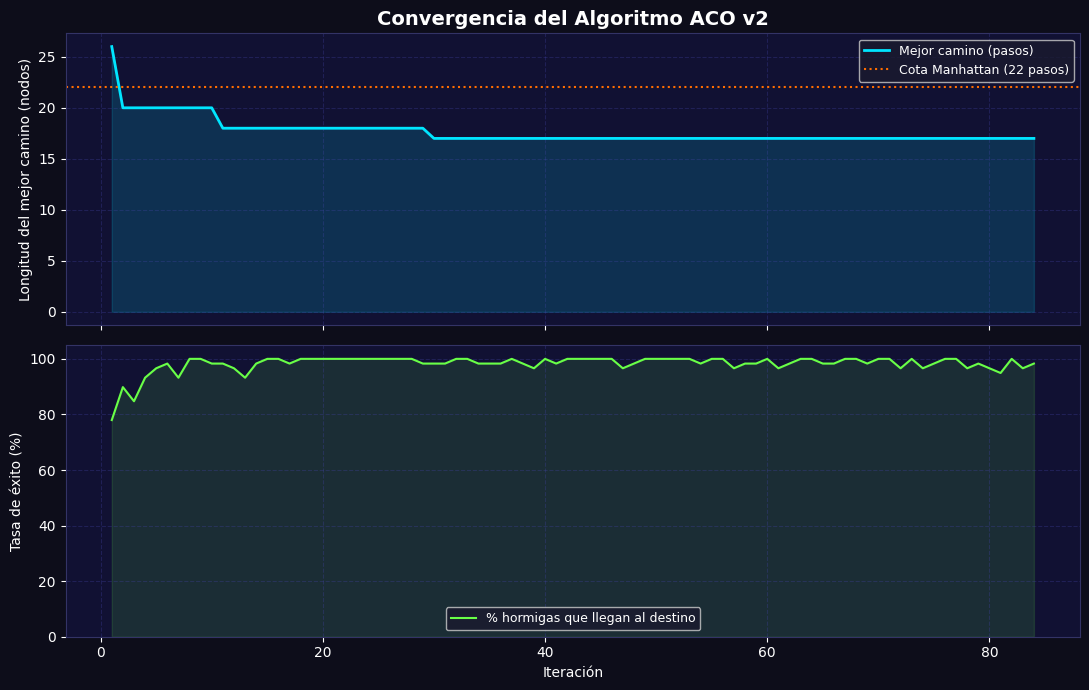

Primera iteración con camino válido : 1
Mejor longitud final                : 17 pasos
Tasa de éxito promedio              : 98.2%


In [7]:
iters_con_camino = [(i+1, l) for i, l in enumerate(historial_mejor) if l is not None]
tasa_exito       = [len(c)/N_ANTS*100 for c in historial_caminos]

if iters_con_camino:
    xs, ys = zip(*iters_con_camino)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    fig.patch.set_facecolor('#0d0d1a')
    for ax in (ax1, ax2):
        ax.set_facecolor('#111133')
        ax.tick_params(colors='white')
        ax.yaxis.label.set_color('white')
        ax.xaxis.label.set_color('white')
        for sp in ax.spines.values(): sp.set_edgecolor('#333366')
        ax.grid(True, linestyle='--', alpha=0.3, color='#4444aa')

    # Curva de convergencia
    ax1.plot(xs, ys, color='#00e5ff', linewidth=2, label='Mejor camino (pasos)')
    ax1.fill_between(xs, ys, alpha=0.15, color='#00e5ff')
    ax1.axhline(y=DIST_MANHATTAN, color='#ff6d00', linestyle=':', linewidth=1.5,
                label=f'Cota Manhattan ({DIST_MANHATTAN} pasos)')
    ax1.set_ylabel('Longitud del mejor camino (nodos)', color='white')
    ax1.set_title('Convergencia del Algoritmo ACO v2', fontsize=14,
                  fontweight='bold', color='white')
    ax1.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')

    # Tasa de éxito
    ax2.plot(range(1, M_ITER+1), tasa_exito, color='#69ff47', linewidth=1.5,
             label='% hormigas que llegan al destino')
    ax2.fill_between(range(1, M_ITER+1), tasa_exito, alpha=0.12, color='#69ff47')
    ax2.set_ylabel('Tasa de éxito (%)', color='white')
    ax2.set_xlabel('Iteración', color='white')
    ax2.set_ylim(0, 105)
    ax2.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')

    plt.tight_layout()
    plt.show()
    print(f"Primera iteración con camino válido : {xs[0]}")
    print(f"Mejor longitud final                : {ys[-1]} pasos")
    print(f"Tasa de éxito promedio              : {sum(tasa_exito)/len(tasa_exito):.1f}%")
else:
    print("No se encontró ningún camino válido.")
    print("Sugerencia: aumentar N_ANTS o reducir OBSTACLE_PCT.")

## **Paso 8 — Animación del experimento**
Visualización frame a frame con mejoras visuales:
- **Fondo inferno** → intensidad de feromonas (negro→rojo→amarillo)
- **Gris oscuro** → obstáculos
- **Verde brillante** → colonia (origen)
- **Rojo brillante** → fuente de comida (destino)
- **Cian** → posiciones actuales de las hormigas
- **Amarillo** → mejor camino encontrado hasta el frame actual

> ⚠️ La animación puede tardar unos segundos en generarse dependiendo de M_ITER.

In [8]:
# ── Precalcular mejor camino acumulado por iteración O(M·N) ──────────────────
mejor_acumulado_por_iter = []
_mejor_hasta = None
_long_min    = float('inf')
for _caminos_i in historial_caminos:
    for _cam in _caminos_i:
        if len(_cam) < _long_min:
            _long_min    = len(_cam)
            _mejor_hasta = _cam
    mejor_acumulado_por_iter.append(_mejor_hasta)

# Colormap inferno para feromonas — más informativo que azul plano
cmap_pher = plt.get_cmap('inferno')

# ── Canvas ────────────────────────────────────────────────────────────────────
fig_anim, (ax_mapa, ax_info) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={'width_ratios': [2, 1]}
)
fig_anim.patch.set_facecolor('#0d0d1a')
for ax in (ax_mapa, ax_info):
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a1a4e')


def construir_frame_rgb(iter_idx):
    """
    Construye la imagen RGB del frame iter_idx.
    Capas (de fondo a frente):
      1. Feromonas normalizadas con colormap inferno
      2. Obstáculos en gris oscuro
      3. Mejor camino acumulado en amarillo
      4. Posiciones actuales de hormigas en cian
      5. Origen en verde, Destino en rojo (siempre encima)
    """
    pher  = historial_feromonas[iter_idx]
    p_max = pher.max()
    p_norm = pher / p_max if p_max > 0 else pher

    # Capa base: colormap inferno sobre feromonas normalizadas
    frame = cmap_pher(p_norm)[:, :, :3].astype(np.float32)

    # Obstáculos
    obs_mask = grid == OBSTACLE
    frame[obs_mask] = [0.08, 0.08, 0.12]

    # Mejor camino acumulado (amarillo)
    mejor_hasta = mejor_acumulado_por_iter[iter_idx]
    if mejor_hasta is not None:
        for r, c in mejor_hasta:
            frame[r, c] = [1.0, 0.95, 0.0]

    # Posiciones de hormigas activas (cian)
    for r, c in historial_posiciones[iter_idx]:
        if (r, c) != FOOD_POS and (r, c) != ORIGIN_POS:
            frame[r, c] = [0.0, 0.9, 1.0]

    # Origen y Destino (siempre visibles encima de todo)
    frame[ORIGIN_POS[0], ORIGIN_POS[1]] = [0.0, 1.0, 0.2]
    frame[FOOD_POS[0],   FOOD_POS[1]]   = [1.0, 0.1, 0.1]

    return frame


frame0  = construir_frame_rgb(0)
im_anim = ax_mapa.imshow(frame0, interpolation='nearest', aspect='equal')
titulo  = ax_mapa.set_title('', color='white', fontsize=12, fontweight='bold')
ax_mapa.set_xlabel('Columnas', color='white')
ax_mapa.set_ylabel('Filas', color='white')

leyenda = [
    mpatches.Patch(color='#7f0000', label='Feromonas (baja)'),
    mpatches.Patch(color='#ffff00', label='Feromonas (alta)'),
    mpatches.Patch(color=(0.08, 0.08, 0.12), label='Obstáculo'),
    mpatches.Patch(color=(0.0, 1.0, 0.2),    label='Origen'),
    mpatches.Patch(color='red',               label='Destino'),
    mpatches.Patch(color='cyan',              label='Hormigas activas'),
    mpatches.Patch(color='yellow',            label='Mejor camino'),
]
ax_mapa.legend(handles=leyenda, loc='upper right', fontsize=7,
               facecolor='#0d0d1a', labelcolor='white', edgecolor='#1a1a4e')

# Panel de información
ax_info.set_xlim(0, 1); ax_info.set_ylim(0, 1)
ax_info.axis('off')
info_text = ax_info.text(
    0.05, 0.97, '', transform=ax_info.transAxes,
    color='white', fontsize=9, verticalalignment='top', fontfamily='monospace'
)
# Barra de progreso
barra_fondo = ax_info.add_patch(
    plt.Rectangle((0.05, 0.04), 0.9, 0.025, color='#333355')
)
barra_prog  = ax_info.add_patch(
    plt.Rectangle((0.05, 0.04), 0.0, 0.025, color='#00e5ff')
)
progreso_label = ax_info.text(
    0.5, 0.02, '', ha='center', color='white', fontsize=7, fontfamily='monospace'
)


def actualizar_frame(i):
    frame       = construir_frame_rgb(i)
    im_anim.set_data(frame)

    long_actual = historial_mejor[i]
    n_exitosas  = len(historial_caminos[i])
    progreso    = (i + 1) / M_ITER

    titulo.set_text(f'ACO v2 — Iteración {i+1} / {M_ITER}')

    info_text.set_text(
        f"{'─'*28}\n"
        f" PARÁMETROS\n"
        f"{'─'*28}\n"
        f" N  hormigas   : {N_ANTS}\n"
        f" M  iteraciones: {M_ITER}\n"
        f" α  feromonas  : {ALPHA}\n"
        f" β  heurística : {BETA}\n"
        f" ρ  evaporación: {RHO}\n"
        f" τ₀ inicial    : {TAU_INIT}\n"
        f" τ_min piso    : {TAU_MIN}\n"
        f" Q  depósito   : {Q}\n"
        f" Mapa          : {COLS}×{ROWS}\n"
        f"{'─'*28}\n"
        f" ITERACIÓN {i+1}\n"
        f"{'─'*28}\n"
        f" Exitosas      : {n_exitosas}/{N_ANTS} ({n_exitosas/N_ANTS*100:.0f}%)\n"
        f" Mejor camino  : {long_actual if long_actual else '—'} pasos\n"
        f" Global mejor  : {mejor_longitud} pasos\n"
        f" Manhattan     : {DIST_MANHATTAN} pasos (cota)\n"
    )

    # Actualizar barra de progreso
    barra_prog.set_width(0.9 * progreso)
    progreso_label.set_text(f'Progreso: {progreso*100:.0f}%')

    return im_anim, titulo, info_text, barra_prog, progreso_label


FRAME_INTERVAL = max(50, 3000 // M_ITER)
ani = animation.FuncAnimation(
    fig_anim, actualizar_frame, frames=M_ITER,
    interval=FRAME_INTERVAL, blit=True, repeat=False
)

plt.tight_layout()
display(HTML(ani.to_jshtml()))
plt.close(fig_anim)
print("Animación generada. Use los controles del reproductor para navegar.")

Animación generada. Use los controles del reproductor para navegar.


## **Paso 9 — Resultado final**
Visualización estática del mejor camino y mapa de calor de feromonas.

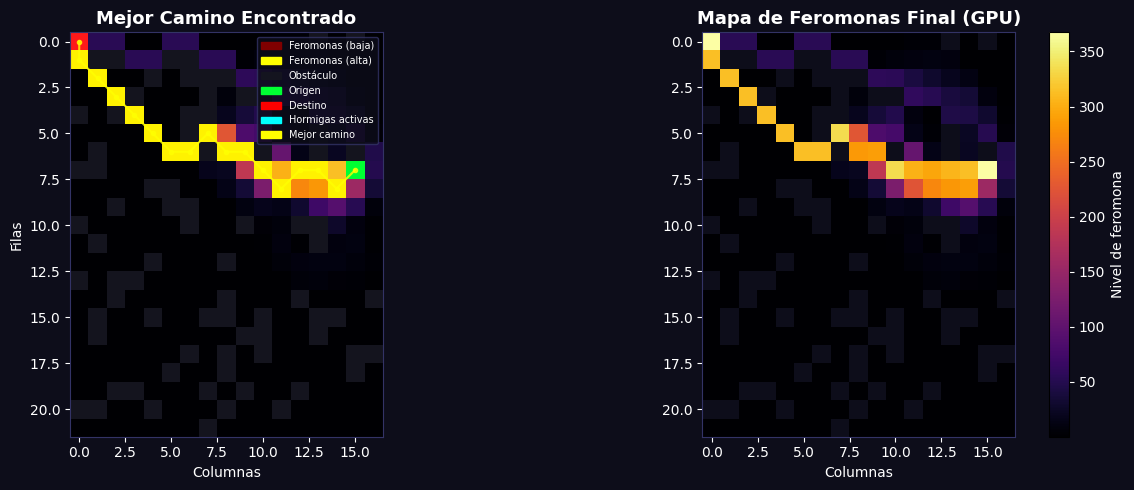

                RESUMEN FINAL
  Seed                 : 5957
  Mapa                 : 17 cols × 22 filas
  Hormigas (N)         : 59
  Iteraciones (M)      : 84
  Mejor camino (pasos) : 17
  Distancia Manhattan  : 22 (cota inferior)
  Eficiencia del camino: 129.4%
  Tiempo total         : 5.75 s
  GPU usada            : Tesla T4
  Kernels GPU          : heuristica, evaporacion, deposito, pesos


In [9]:
fig_final, axes_f = plt.subplots(1, 2, figsize=(13, 5))
fig_final.patch.set_facecolor('#0d0d1a')
for ax in axes_f:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333366')

# ── Mapa con mejor camino ────────────────────────────────────────────────────
frame_final = construir_frame_rgb(M_ITER - 1)
axes_f[0].imshow(frame_final, interpolation='nearest')
axes_f[0].set_title('Mejor Camino Encontrado', fontsize=13, fontweight='bold', color='white')
axes_f[0].set_xlabel('Columnas', color='white')
axes_f[0].set_ylabel('Filas', color='white')
axes_f[0].legend(handles=leyenda, loc='upper right', fontsize=7,
                 facecolor='#0d0d1a', labelcolor='white', edgecolor='#333366')

# Superponer el camino óptimo como línea
if mejor_camino:
    ys_path = [p[0] for p in mejor_camino]
    xs_path = [p[1] for p in mejor_camino]
    axes_f[0].plot(xs_path, ys_path, '-o', color='yellow',
                   markersize=3, linewidth=1.5, alpha=0.8)

# ── Mapa de calor de feromonas final ─────────────────────────────────────────
pher_final = historial_feromonas[-1].copy()
pher_final[grid == OBSTACLE] = np.nan
im_heat = axes_f[1].imshow(pher_final, cmap='inferno', interpolation='nearest')
axes_f[1].set_title('Mapa de Feromonas Final (GPU)', fontsize=13, fontweight='bold', color='white')
axes_f[1].set_xlabel('Columnas', color='white')
cb = plt.colorbar(im_heat, ax=axes_f[1], label='Nivel de feromona')
cb.ax.yaxis.label.set_color('white')
cb.ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

# ── Resumen final ─────────────────────────────────────────────────────────────
print("="*55)
print("                RESUMEN FINAL")
print("="*55)
print(f"  Seed                 : {SEED}")
print(f"  Mapa                 : {COLS} cols × {ROWS} filas")
print(f"  Hormigas (N)         : {N_ANTS}")
print(f"  Iteraciones (M)      : {M_ITER}")
print(f"  Mejor camino (pasos) : {mejor_longitud}")
print(f"  Distancia Manhattan  : {DIST_MANHATTAN} (cota inferior)")
print(f"  Eficiencia del camino: {DIST_MANHATTAN/mejor_longitud*100:.1f}%")
print(f"  Tiempo total         : {t_total:.2f} s")
print(f"  GPU usada            : {gpu.name}")
print(f"  Kernels GPU          : heuristica, evaporacion, deposito, pesos")
print("="*55)